# Import Libraries

In [7]:
!/usr/local/bin/python3.11 -m pip install geopandas contextily

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

DEPRECATION: Loading egg at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz-0.18.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip3.11 install --upgrade pip


# Setup

In [3]:
# Load ACS
acs = pd.read_csv("acs_bayarea_2009_2022_all_tables.csv",
                  dtype={"GEOID": str})

# Create county GEOID 
acs["county_geoid"] = acs["GEOID"].str[:5]

# map county FIPS to county name 
county_fips_to_name = {
    "06001": "Alameda",
    "06013": "Contra Costa",
    "06075": "San Francisco",
    "06081": "San Mateo",
    "06085": "Santa Clara",
}
acs["county_name"] = acs["county_geoid"].map(county_fips_to_name)

# tract ACS data county + year

def pop_weighted_mean(group, value_col):
    w = group["total_pop"]
    v = group[value_col]
    return (v * w).sum() / w.sum()

county_year = (
    acs.groupby(["county_geoid", "county_name", "year"])
    .apply(
        lambda g: pd.Series({
            "total_pop": g["total_pop"].sum(),
            "median_home_value": pop_weighted_mean(g, "median_home_value"),
            "median_income": pop_weighted_mean(g, "median_income"),
            "pct_poc": pop_weighted_mean(g, "pct_poc"),
        })
    )
    .reset_index()
)

# Load HOLC bay area
holc = gpd.read_file("holc_bayarea.json")

# Collapse multiple HOLC polygons per county into ONE county geometry
gdf_counties = (
    holc[["GEOID", "NAME", "geometry"]]
    .dissolve(by=["GEOID", "NAME"])
    .reset_index()
)

# Merge county geometries with ACS
gdf_merged = gdf_counties.merge(
    county_year,
    left_on="GEOID",
    right_on="county_geoid",
    how="left"
)

# check
display(gdf_merged[gdf_merged["year"] == 2022][
    ["GEOID", "NAME", "median_home_value", "pct_poc"]
].head())

/var/folders/50/0k_k4rt15xs1zvrpdy6tqxz80000gn/T/ipykernel_39514/1541369214.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,GEOID,NAME,median_home_value,pct_poc
13,06001,Alameda,9.894843e+05,0.707029
27,06013,Contra Costa,8.560677e+05,0.594244
41,06075,San Francisco,1.308964e+06,0.617055
55,06081,San Mateo,1.434872e+06,0.629811
69,06085,Santa Clara,1.296834e+06,0.708315


# Median home value across Bay Area (map)

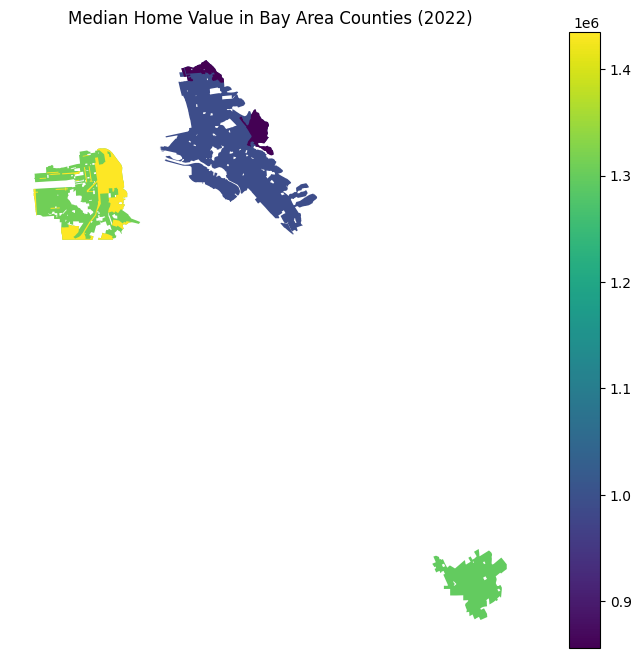

In [15]:
year_to_plot = 2022 

plot_data = gdf_merged[gdf_merged["year"] == 
year_to_plot].dropna( 
    subset=["geometry", "median_home_value"] 
    ) 

fig, ax = plt.subplots(figsize=(10, 8)) 

plot_data.plot( column="median_home_value", 
    cmap="viridis", 
    legend=True, 
    ax=ax 
    ) 

ax.set_title(f"Median Home Value in Bay Area Counties ({year_to_plot})") 

ax.axis("off") 

plt.show()

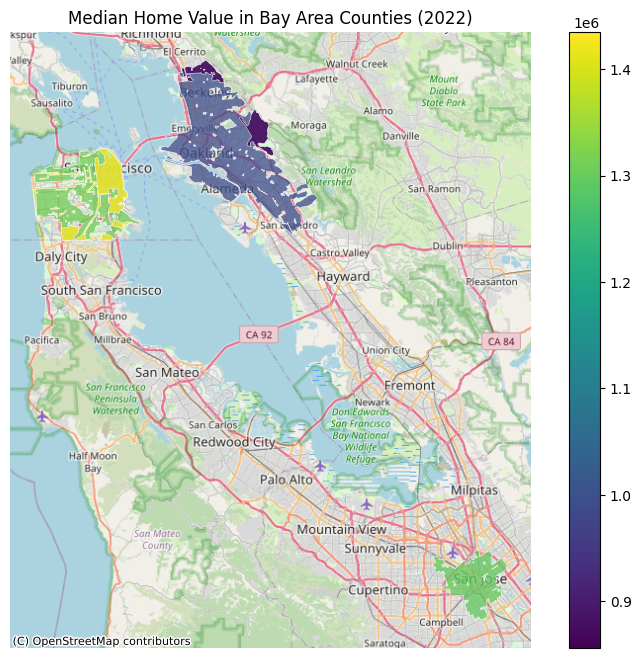

In [14]:
year_to_plot = 2022

plot_data = (
    gdf_merged[gdf_merged["year"] == year_to_plot]
    .dropna(subset=["geometry", "median_home_value"])
)

# CRS
if plot_data.crs is None:
    plot_data = plot_data.set_crs("EPSG:4326")

# basemap tiles
plot_data_3857 = plot_data.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

plot_data_3857.plot(
    column="median_home_value",
    cmap="viridis",
    legend=True,
    ax=ax,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5,
)

# map underneath
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"Median Home Value in Bay Area Counties ({year_to_plot})")
ax.axis("off")
plt.show()


# % People of Color (POC) distribution (map)

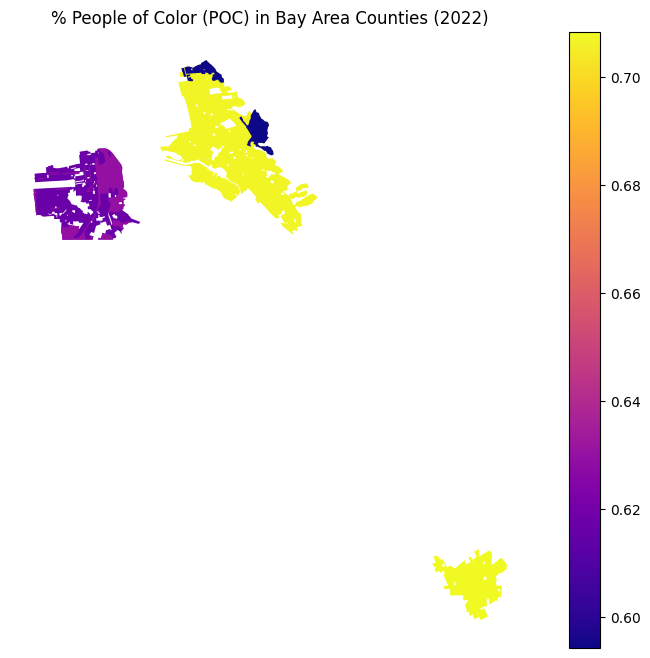

In [16]:
year_to_plot = 2022

plot_data = gdf_merged[gdf_merged["year"] == year_to_plot].dropna(
    subset=["geometry", "pct_poc"]
)

fig, ax = plt.subplots(figsize=(10, 8))

plot_data.plot(
    column="pct_poc",
    cmap="plasma",
    legend=True,
    ax=ax
)

ax.set_title(f"% People of Color (POC) in Bay Area Counties ({year_to_plot})")
ax.axis("off")

plt.show()

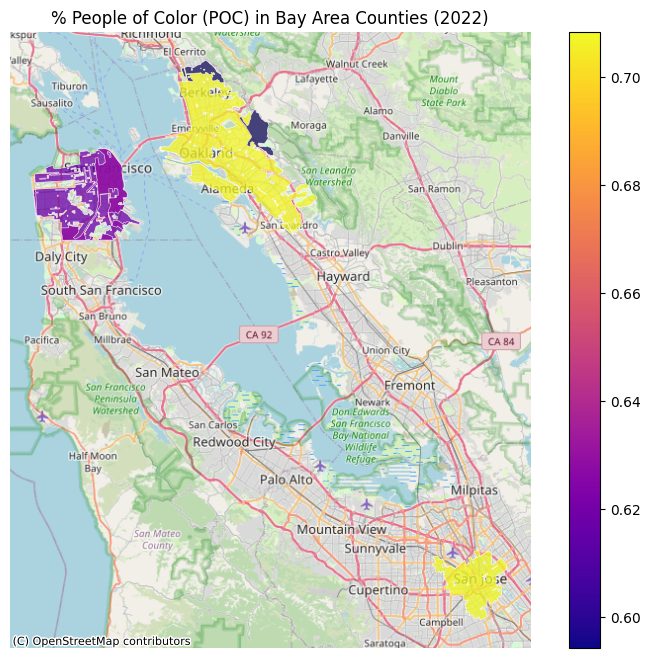

In [13]:
year_to_plot = 2022

plot_data = (
    gdf_merged[gdf_merged["year"] == year_to_plot]
    .dropna(subset=["geometry", "pct_poc"])
)

if plot_data.crs is None:
    plot_data = plot_data.set_crs("EPSG:4326")

plot_data_3857 = plot_data.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

plot_data_3857.plot(
    column="pct_poc",
    cmap="plasma",
    legend=True,
    ax=ax,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"% People of Color (POC) in Bay Area Counties ({year_to_plot})")
ax.axis("off")

plt.show()

# Line plot: Median home value over time by county

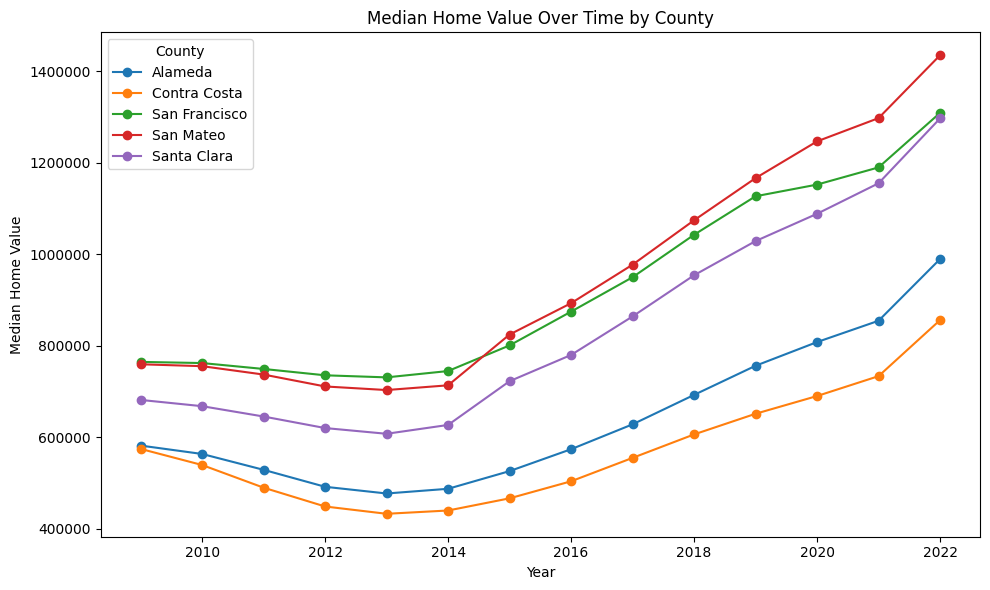

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ensure proper ordering by year
data = county_year.sort_values(["county_name", "year"])

for county, group in data.groupby("county_name"):
    ax.plot(group["year"], group["median_home_value"], marker="o", label=county)

ax.set_title("Median Home Value Over Time by County")
ax.set_xlabel("Year")
ax.set_ylabel("Median Home Value")
ax.ticklabel_format(axis="y", style="plain")  # avoid scientific notation
ax.legend(title="County")
plt.tight_layout()
plt.show()

#  Line plot: Median income over time by county

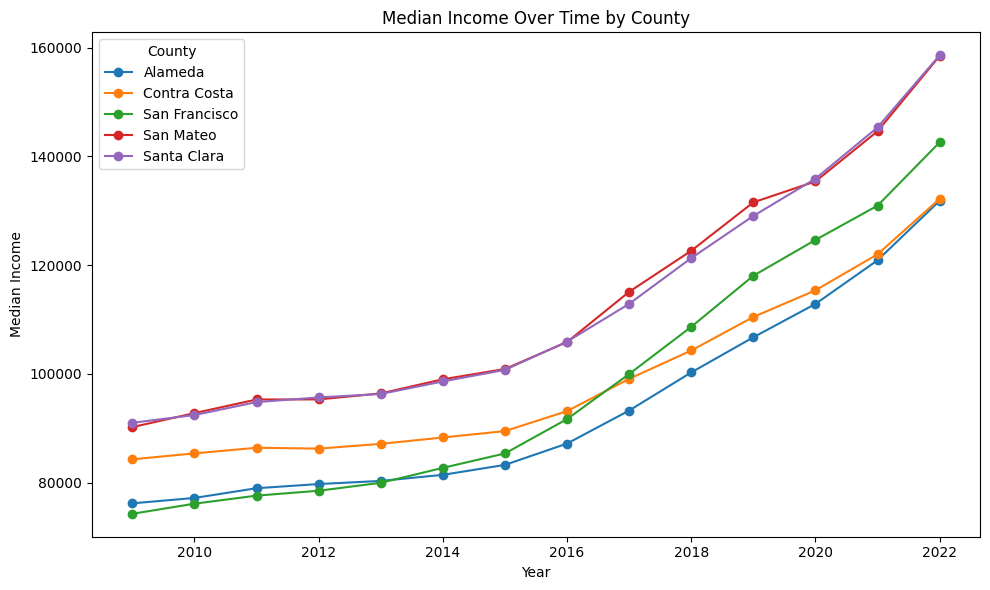

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

data = county_year.sort_values(["county_name", "year"])

for county, group in data.groupby("county_name"):
    ax.plot(group["year"], group["median_income"], marker="o", label=county)

ax.set_title("Median Income Over Time by County")
ax.set_xlabel("Year")
ax.set_ylabel("Median Income")
ax.ticklabel_format(axis="y", style="plain")
ax.legend(title="County")
plt.tight_layout()
plt.show()

#  %POC change over time

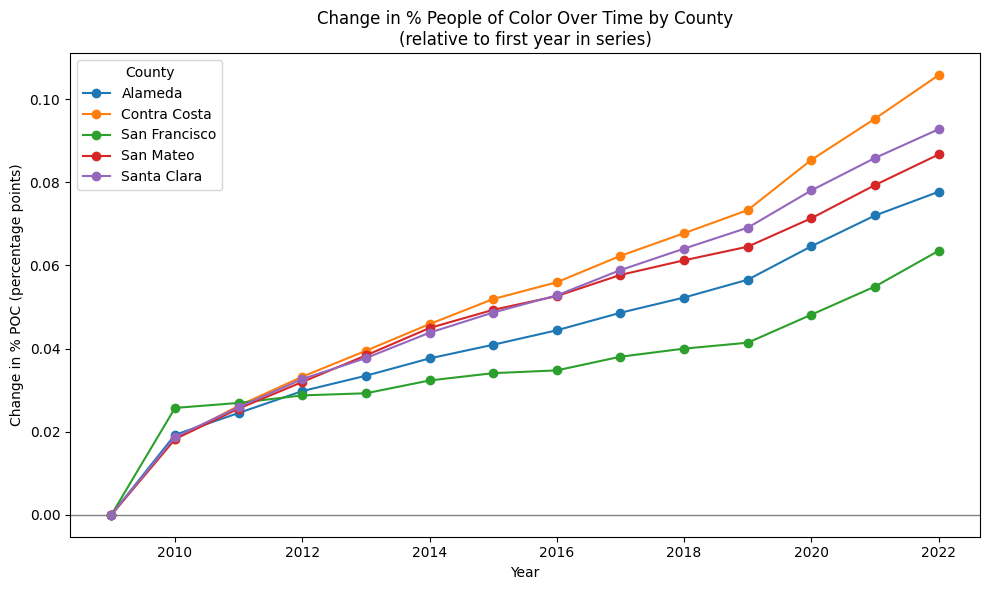

In [10]:
data = county_year.sort_values(["county_name", "year"]).copy()

# Compute change from first year per county
data["pct_poc_change"] = data.groupby("county_name")["pct_poc"].transform(
    lambda s: s - s.iloc[0]
)

fig, ax = plt.subplots(figsize=(10, 6))

for county, group in data.groupby("county_name"):
    ax.plot(group["year"], group["pct_poc_change"], marker="o", label=county)

ax.set_title("Change in % People of Color Over Time by County\n(relative to first year in series)")
ax.set_xlabel("Year")
ax.set_ylabel("Change in % POC (percentage points)")
ax.axhline(0, color="gray", linewidth=1)
ax.legend(title="County")
plt.tight_layout()
plt.show()

#  Scatterplot: %POC vs Median home value

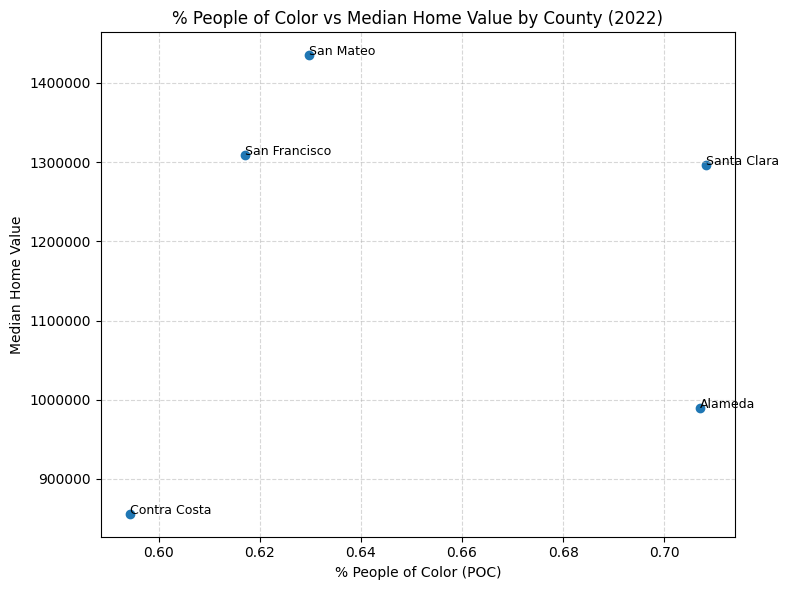

In [15]:
year_to_plot = 2022 

scatter_data = county_year[county_year["year"] == year_to_plot].dropna(
    subset=["pct_poc", "median_home_value"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(scatter_data["pct_poc"], scatter_data["median_home_value"])

# Add county labels next to points
for _, row in scatter_data.iterrows():
    ax.text(row["pct_poc"],
            row["median_home_value"],
            row["county_name"],
            fontsize=9)

ax.set_title(f"% People of Color vs Median Home Value by County ({year_to_plot})")
ax.set_xlabel("% People of Color (POC)")
ax.set_ylabel("Median Home Value")
ax.ticklabel_format(axis="y", style="plain")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()